In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from Scratch.neuralnet import Value, Neuron, Layer, MLP
from Scratch.brain import Value


In [3]:
np.random.seed(1337)
random.seed(1337)

In [4]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

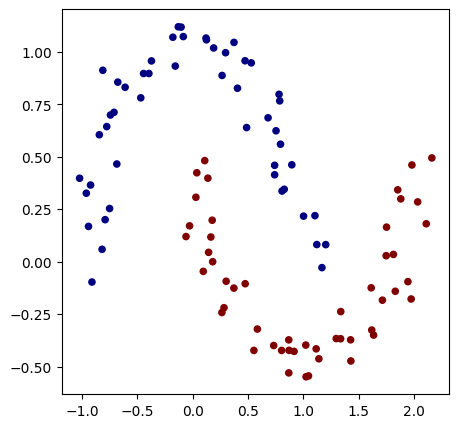

In [5]:
y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [6]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print("number of parameters", len(model.parameters()))

number of parameters 337


In [7]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # 1. Forward the model to get scores
    # Scores will be between -1 and 1 because of tanh
    scores = list(map(model, inputs))
    
    # 2. Mean Squared Error (MSE) Loss
    # Formula: sum((prediction - target)^2)
    losses = [(scorei - yi)**2 for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    # 3. Proper L2 regularization
    # This penalizes the 'norm' of the weights to prevent overfitting
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    
    total_loss = data_loss + reg_loss
    
    # 4. Get accuracy
    # Since tanh output is -1 to 1, we check if the sign matches
    # (scorei.data > 0) is a proxy for prediction, (yi > 0) is proxy for label
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(f"Total Loss: {total_loss.data:.4f} | Accuracy: {acc*100:.2f}%")

Total Loss: 1.0980 | Accuracy: 68.00%


In [8]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 10 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 1.0980204669338722, accuracy 68.0%
step 10 loss 0.4469043489584673, accuracy 87.0%
step 20 loss 0.19490850460871567, accuracy 92.0%
step 30 loss 0.018405618820496995, accuracy 100.0%
step 40 loss 0.017242290787092864, accuracy 100.0%
step 50 loss 0.01672585834215136, accuracy 100.0%
step 60 loss 0.016399638889359164, accuracy 100.0%
step 70 loss 0.0161778860712798, accuracy 100.0%
step 80 loss 0.016025626392051254, accuracy 100.0%
step 90 loss 0.01592486408526432, accuracy 100.0%


(-1.548639298268643, 1.951360701731357)

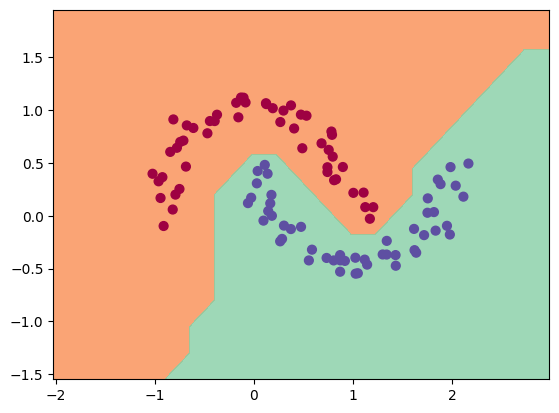

In [9]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())